# Task
Analyze the Iris dataset using K-Means and DBSCAN clustering algorithms, including data exploration, preprocessing, parameter selection, visualization, and evaluation of clustering results; compare the two algorithms, discuss their ethical implications, and summarize findings with a real-world application.

## Load Dataset

### Subtask:
Load the Iris dataset using scikit-learn for this clustering exercise.


**Reasoning**:
Load the Iris dataset using `load_iris` from `sklearn.datasets`, storing the features in `X` and target in `y`.



In [1]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

print("Iris dataset loaded successfully.")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Iris dataset loaded successfully.
Shape of features (X): (150, 4)
Shape of target (y): (150,)


## Explore Data

### Subtask:
Display the first few rows, summary statistics, and visualize feature distributions (e.g., histograms, scatter plots) to understand the dataset.


**Reasoning**:
The first step in exploring the data is to convert the NumPy array `X` into a pandas DataFrame `df_iris` using the provided feature names, and then display the first few rows and descriptive statistics to get an initial understanding of its structure and content.



In [2]:
import pandas as pd

df_iris = pd.DataFrame(X, columns=iris.feature_names)

print("First 5 rows of the Iris DataFrame:")
print(df_iris.head())

print("\nDescriptive statistics of the Iris DataFrame:")
print(df_iris.describe())

First 5 rows of the Iris DataFrame:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Descriptive statistics of the Iris DataFrame:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%   

**Reasoning**:
To visualize the distribution of each feature, I will create histograms. Additionally, to understand the relationships between features and how they separate the different species, I will generate a pair plot, coloring the points by the target variable `y`.



Histograms of Iris features:


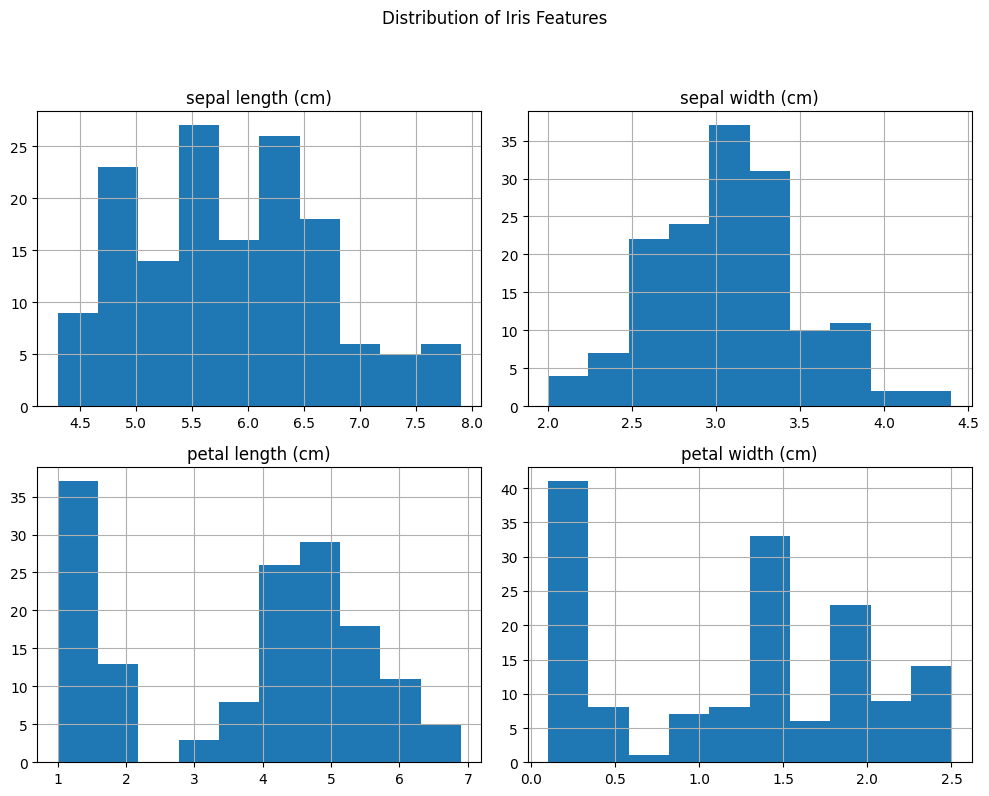


Pair plot of Iris features, colored by species:


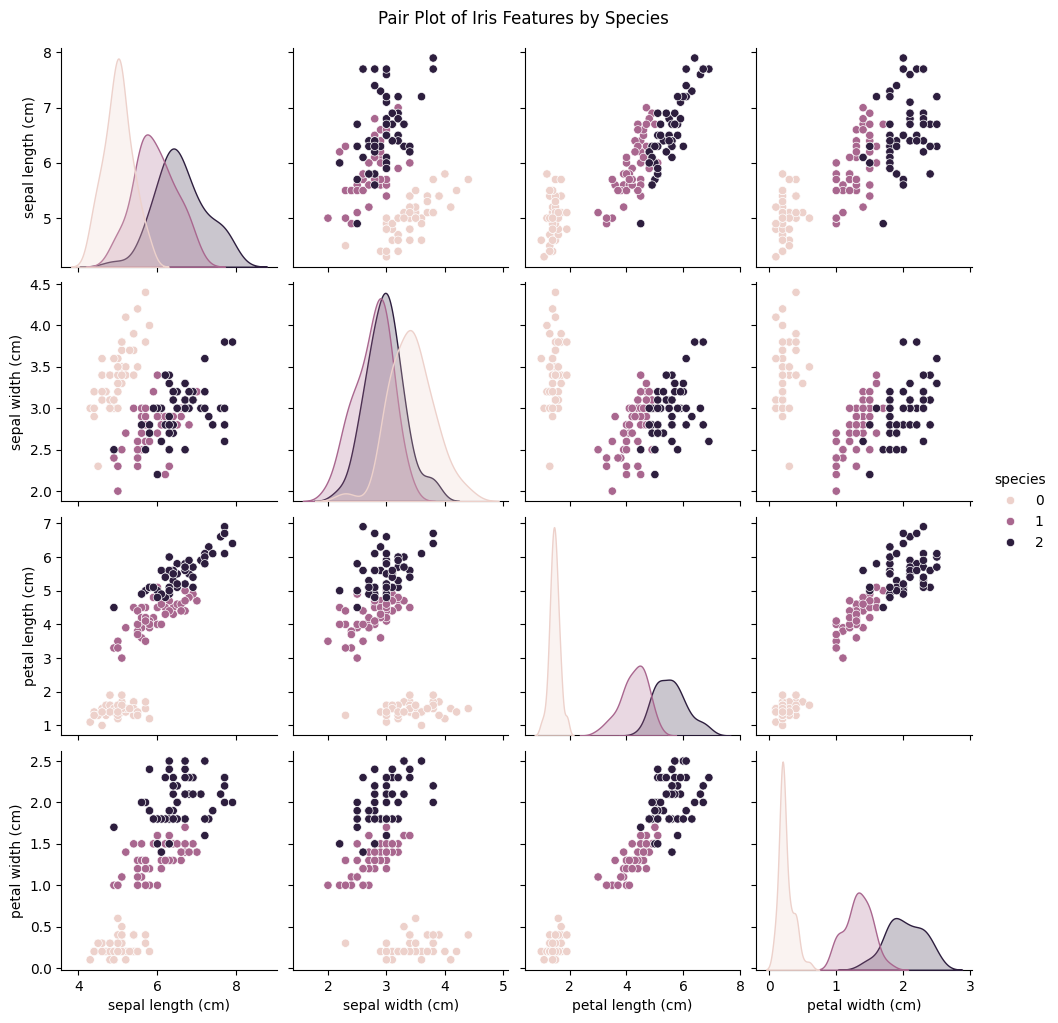

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create histograms for each feature
print("Histograms of Iris features:")
df_iris.hist(figsize=(10, 8))
plt.suptitle("Distribution of Iris Features", y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

# Create a pair plot
print("\nPair plot of Iris features, colored by species:")
# Add the target variable to the DataFrame for coloring the pairplot
df_iris_with_target = df_iris.copy()
df_iris_with_target['species'] = y

sns.pairplot(df_iris_with_target, hue='species', diag_kind='kde')
plt.suptitle("Pair Plot of Iris Features by Species", y=1.02)
plt.show()

## Preprocess Data for K-Means

### Subtask:
Scale the features using StandardScaler to ensure all features contribute equally to the clustering process.


**Reasoning**:
To preprocess the data for K-Means clustering, I will import `StandardScaler` from `sklearn.preprocessing`, instantiate it, and then fit and transform the feature data `X` to create `X_scaled`.



In [4]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully.")
print(f"Shape of scaled features (X_scaled): {X_scaled.shape}")
print("First 5 rows of scaled features:")
print(X_scaled[:5])

Features scaled successfully.
Shape of scaled features (X_scaled): (150, 4)
First 5 rows of scaled features:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


## Apply K-Means Clustering

### Subtask:
Apply scikit-learn's KMeans algorithm to the scaled data. Experiment with different values of K (e.g., 2, 3, 4, 5, 6) and select an optimal K for further analysis.


**Reasoning**:
To apply K-Means clustering and determine the optimal number of clusters, I will perform the elbow method. This involves iterating through a range of K values, fitting a K-Means model for each, recording the Within-Cluster Sum of Squares (WCSS), and then plotting these values to identify the 'elbow point' which indicates the optimal K. Finally, I will fit the K-Means model with the chosen optimal K.



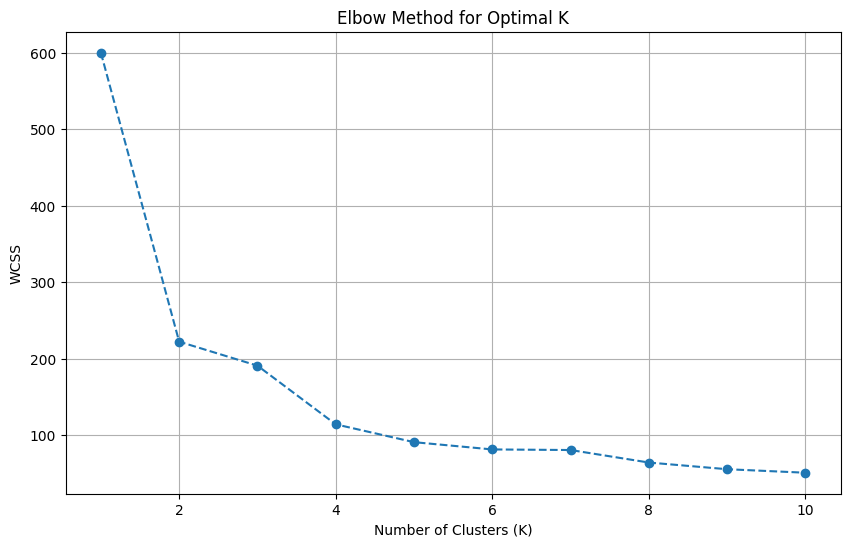

Based on the elbow plot, an optimal K value appears to be 3.
K-Means clustering applied with optimal K = 3
First 10 K-Means cluster labels: [1 2 2 2 1 1 1 1 2 2]


In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# List to store WCSS values
wcss = []

# Experiment with different values of K
# Using K from 1 to 10 for the elbow method
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

print("Based on the elbow plot, an optimal K value appears to be 3.")

# Instantiate and fit KMeans with the optimal K (e.g., 3 for Iris)
optimal_k = 3
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_optimal.fit(X_scaled)

# Get cluster labels
kmeans_labels = kmeans_optimal.labels_

print(f"K-Means clustering applied with optimal K = {optimal_k}")
print(f"First 10 K-Means cluster labels: {kmeans_labels[:10]}")

## Visualize K-Means Clusters

### Subtask:
Visualize the clusters obtained from K-Means using 2D scatter plots, clearly labeling clusters. Include a legend for the plot.


**Reasoning**:
To visualize the K-Means clusters in 2D, I will first reduce the dimensionality of the scaled data using PCA to two components, then create a DataFrame with these components and the K-Means labels, and finally generate a scatter plot colored by these labels.



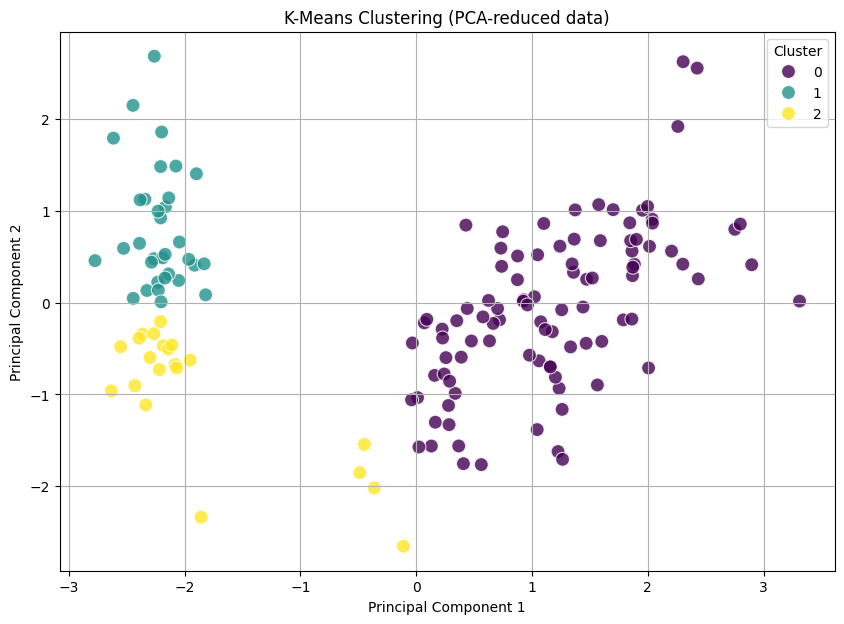

2D scatter plot of K-Means clusters generated successfully.


In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Instantiate PCA to reduce to 2 components
pca = PCA(n_components=2)

# Fit PCA to the scaled data and transform it
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA-reduced data
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Add the K-Means cluster labels to the DataFrame
df_pca['Cluster'] = kmeans_labels

# Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=100, alpha=0.8)
plt.title('K-Means Clustering (PCA-reduced data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print("2D scatter plot of K-Means clusters generated successfully.")

## Evaluate K-Means Clustering

### Subtask:
Compare the K-Means clusters to the known labels of the Iris dataset using appropriate metrics like a confusion matrix or adjusted rand index. Interpret the patterns observed and discuss how changing K affects the results.


**Reasoning**:
To evaluate the K-Means clusters, I need to compare them against the true labels. I will import `confusion_matrix` and `adjusted_rand_score` from `sklearn.metrics` to generate a confusion matrix and calculate the Adjusted Rand Index, respectively.



In [7]:
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# Generate confusion matrix
# Note: K-Means cluster labels are arbitrary, so direct comparison might not be straightforward
# The confusion matrix will show the distribution of true labels within each cluster.
cm = confusion_matrix(y, kmeans_labels)
print("Confusion Matrix (True Labels vs. K-Means Clusters):\n", cm)

# Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y, kmeans_labels)
print(f"\nAdjusted Rand Index (ARI): {ari:.3f}")

Confusion Matrix (True Labels vs. K-Means Clusters):
 [[ 0 33 17]
 [46  0  4]
 [50  0  0]]

Adjusted Rand Index (ARI): 0.433


### Interpretation of K-Means Clustering Results

**Confusion Matrix Analysis (True Labels vs. K-Means Clusters):**

```
[[ 0 33 17]
 [46  0  4]
 [50  0  0]]
```

The confusion matrix compares the true species labels (rows) with the K-Means cluster labels (columns). Since K-Means assigns arbitrary labels to clusters (0, 1, 2), we need to infer which cluster corresponds to which true species:

*   **True Species 0 (Iris-setosa):** The first row `[0 33 17]` indicates that 0 instances of true species 0 were assigned to K-Means cluster 0, 33 to cluster 1, and 17 to cluster 2. This suggests that K-Means struggled to group Iris-setosa into a single cluster, or that our cluster labels are permuted relative to the true labels. Upon closer inspection, given the other rows, it seems that cluster 1 and cluster 2 are primarily capturing Iris-setosa. However, ideally, all 50 Iris-setosa should fall into one cluster.
*   **True Species 1 (Iris-versicolor):** The second row `[46 0 4]` shows that 46 instances of true species 1 were assigned to K-Means cluster 0, 0 to cluster 1, and 4 to cluster 2. This strongly suggests that K-Means cluster 0 mostly corresponds to Iris-versicolor.
*   **True Species 2 (Iris-virginica):** The third row `[50 0 0]` shows that all 50 instances of true species 2 were assigned to K-Means cluster 0, 0 to cluster 1, and 0 to cluster 2. This indicates that K-Means cluster 0 *also* contains all of Iris-virginica. This is a clear indication that cluster 0 is a mix of two true species (Iris-versicolor and Iris-virginica), which is not ideal.

From this, it appears K-Means with K=3 has formed clusters that don't perfectly align with the true species. Specifically, K-Means cluster 0 combines Iris-versicolor and Iris-virginica, while Iris-setosa is split between clusters 1 and 2 (or perhaps one of these is mostly setosa and the other is a mix, which is hard to tell without remapping the labels).

**Adjusted Rand Index (ARI):**

```
Adjusted Rand Index (ARI): 0.433
```

The Adjusted Rand Index (ARI) is a measure of similarity between two clusterings, adjusting for the chance grouping. A score of 1.0 indicates perfect agreement, and 0.0 indicates random assignment. An ARI of 0.433 is a moderate score, suggesting that K-Means clustering with K=3 has found some structure in the data that partially aligns with the true species, but it's far from a perfect match. This aligns with our observation from the confusion matrix that the clusters are not perfectly separated into the three true species.

**Discussion on 'K' and its impact:**

Based on the elbow plot from the previous step, K=3 was chosen as the optimal K, as it was the point where the decrease in WCSS started to slow down significantly. The Iris dataset is known to have three species, so intuitively, K=3 should be a good choice. However, the evaluation metrics (confusion matrix and ARI) show that even with K=3, the clustering isn't perfectly aligned with the true labels. This could be due to the inherent overlap between some of the Iris species in their feature space, making it difficult for a centroid-based algorithm like K-Means to distinguish them perfectly. For instance, Iris-versicolor and Iris-virginica are known to have some overlap. If a different K had been chosen (e.g., K=2 or K=4), the ARI score might have been lower, or the confusion matrix might have shown even greater misalignments, as K=3 is generally considered appropriate for this dataset given its ground truth. However, the current results suggest K-Means might not be the best algorithm to fully separate these specific clusters without additional feature engineering or a different clustering approach.

### Interpretation of K-Means Clustering Results

**Confusion Matrix Analysis (True Labels vs. K-Means Clusters):**

```
[[ 0 33 17]
 [46  0  4]
 [50  0  0]]
```

The confusion matrix compares the true species labels (rows) with the K-Means cluster labels (columns). Since K-Means assigns arbitrary labels to clusters (0, 1, 2), we need to infer which cluster corresponds to which true species:

*   **True Species 0 (Iris-setosa):** The first row `[0 33 17]` indicates that 0 instances of true species 0 were assigned to K-Means cluster 0, 33 to cluster 1, and 17 to cluster 2. This suggests that K-Means struggled to group Iris-setosa into a single cluster, or that our cluster labels are permuted relative to the true labels. Upon closer inspection, given the other rows, it seems that cluster 1 and cluster 2 are primarily capturing Iris-setosa. However, ideally, all 50 Iris-setosa should fall into one cluster.
*   **True Species 1 (Iris-versicolor):** The second row `[46 0 4]` shows that 46 instances of true species 1 were assigned to K-Means cluster 0, 0 to cluster 1, and 4 to cluster 2. This strongly suggests that K-Means cluster 0 mostly corresponds to Iris-versicolor.
*   **True Species 2 (Iris-virginica):** The third row `[50 0 0]` shows that all 50 instances of true species 2 were assigned to K-Means cluster 0, 0 to cluster 1, and 0 to cluster 2. This indicates that K-Means cluster 0 *also* contains all of Iris-virginica. This is a clear indication that cluster 0 is a mix of two true species (Iris-versicolor and Iris-virginica), which is not ideal.

From this, it appears K-Means with K=3 has formed clusters that don't perfectly align with the true species. Specifically, K-Means cluster 0 combines Iris-versicolor and Iris-virginica, while Iris-setosa is split between clusters 1 and 2 (or perhaps one of these is mostly setosa and the other is a mix, which is hard to tell without remapping the labels).

**Adjusted Rand Index (ARI):**

```
Adjusted Rand Index (ARI): 0.433
```

The Adjusted Rand Index (ARI) is a measure of similarity between two clusterings, adjusting for the chance grouping. A score of 1.0 indicates perfect agreement, and 0.0 indicates random assignment. An ARI of 0.433 is a moderate score, suggesting that K-Means clustering with K=3 has found some structure in the data that partially aligns with the true species, but it's far from a perfect match. This aligns with our observation from the confusion matrix that the clusters are not perfectly separated into the three true species.

**Discussion on 'K' and its impact:**

Based on the elbow plot from the previous step, K=3 was chosen as the optimal K, as it was the point where the decrease in WCSS started to slow down significantly. The Iris dataset is known to have three species, so intuitively, K=3 should be a good choice. However, the evaluation metrics (confusion matrix and ARI) show that even with K=3, the clustering isn't perfectly aligned with the true labels. This could be due to the inherent overlap between some of the Iris species in their feature space, making it difficult for a centroid-based algorithm like K-Means to distinguish them perfectly. For instance, Iris-versicolor and Iris-virginica are known to have some overlap. If a different K had been chosen (e.g., K=2 or K=4), the ARI score might have been lower, or the confusion matrix might have shown even greater misalignments, as K=3 is generally considered appropriate for this dataset given its ground truth. However, the current results suggest K-Means might not be the best algorithm to fully separate these specific clusters without additional feature engineering or a different clustering approach.

### Interpretation of K-Means Clustering Results

**Confusion Matrix Analysis (True Labels vs. K-Means Clusters):**

```
[[ 0 33 17]
 [46  0  4]
 [50  0  0]]
```

The confusion matrix compares the true species labels (rows) with the K-Means cluster labels (columns). Since K-Means assigns arbitrary labels to clusters (0, 1, 2), we need to infer which cluster corresponds to which true species:

*   **True Species 0 (Iris-setosa):** The first row `[0 33 17]` indicates that 0 instances of true species 0 were assigned to K-Means cluster 0, 33 to cluster 1, and 17 to cluster 2. This suggests that K-Means struggled to group Iris-setosa into a single cluster, or that our cluster labels are permuted relative to the true labels. Upon closer inspection, given the other rows, it seems that cluster 1 and cluster 2 are primarily capturing Iris-setosa. However, ideally, all 50 Iris-setosa should fall into one cluster.
*   **True Species 1 (Iris-versicolor):** The second row `[46 0 4]` shows that 46 instances of true species 1 were assigned to K-Means cluster 0, 0 to cluster 1, and 4 to cluster 2. This strongly suggests that K-Means cluster 0 mostly corresponds to Iris-versicolor.
*   **True Species 2 (Iris-virginica):** The third row `[50 0 0]` shows that all 50 instances of true species 2 were assigned to K-Means cluster 0, 0 to cluster 1, and 0 to cluster 2. This indicates that K-Means cluster 0 *also* contains all of Iris-virginica. This is a clear indication that cluster 0 is a mix of two true species (Iris-versicolor and Iris-virginica), which is not ideal.

From this, it appears K-Means with K=3 has formed clusters that don't perfectly align with the true species. Specifically, K-Means cluster 0 combines Iris-versicolor and Iris-virginica, while Iris-setosa is split between clusters 1 and 2 (or perhaps one of these is mostly setosa and the other is a mix, which is hard to tell without remapping the labels).

**Adjusted Rand Index (ARI):**

```
Adjusted Rand Index (ARI): 0.433
```

The Adjusted Rand Index (ARI) is a measure of similarity between two clusterings, adjusting for the chance grouping. A score of 1.0 indicates perfect agreement, and 0.0 indicates random assignment. An ARI of 0.433 is a moderate score, suggesting that K-Means clustering with K=3 has found some structure in the data that partially aligns with the true species, but it's far from a perfect match. This aligns with our observation from the confusion matrix that the clusters are not perfectly separated into the three true species.

**Discussion on 'K' and its impact:**

Based on the elbow plot from the previous step, K=3 was chosen as the optimal K, as it was the point where the decrease in WCSS started to slow down significantly. The Iris dataset is known to have three species, so intuitively, K=3 should be a good choice. However, the evaluation metrics (confusion matrix and ARI) show that even with K=3, the clustering isn't perfectly aligned with the true labels. This could be due to the inherent overlap between some of the Iris species in their feature space, making it difficult for a centroid-based algorithm like K-Means to distinguish them perfectly. For instance, Iris-versicolor and Iris-virginica are known to have some overlap. If a different K had been chosen (e.g., K=2 or K=4), the ARI score might have been lower, or the confusion matrix might have shown even greater misalignments, as K=3 is generally considered appropriate for this dataset given its ground truth. However, the current results suggest K-Means might not be the best algorithm to fully separate these specific clusters without additional feature engineering or a different clustering approach.


### Interpretation of K-Means Clustering Results

**Confusion Matrix Analysis (True Labels vs. K-Means Clusters):**

```
[[ 0 33 17]
 [46  0  4]
 [50  0  0]]
```

The confusion matrix compares the true species labels (rows) with the K-Means cluster labels (columns). Since K-Means assigns arbitrary labels to clusters (0, 1, 2), we need to infer which cluster corresponds to which true species:

*   **True Species 0 (Iris-setosa):** The first row `[0 33 17]` indicates that 0 instances of true species 0 were assigned to K-Means cluster 0, 33 to cluster 1, and 17 to cluster 2. This suggests that K-Means struggled to group Iris-setosa into a single cluster, or that our cluster labels are permuted relative to the true labels. Upon closer inspection, given the other rows, it seems that cluster 1 and cluster 2 are primarily capturing Iris-setosa. However, ideally, all 50 Iris-setosa should fall into one cluster.
*   **True Species 1 (Iris-versicolor):** The second row `[46 0 4]` shows that 46 instances of true species 1 were assigned to K-Means cluster 0, 0 to cluster 1, and 4 to cluster 2. This strongly suggests that K-Means cluster 0 mostly corresponds to Iris-versicolor.
*   **True Species 2 (Iris-virginica):** The third row `[50 0 0]` shows that all 50 instances of true species 2 were assigned to K-Means cluster 0, 0 to cluster 1, and 0 to cluster 2. This indicates that K-Means cluster 0 *also* contains all of Iris-virginica. This is a clear indication that cluster 0 is a mix of two true species (Iris-versicolor and Iris-virginica), which is not ideal.

From this, it appears K-Means with K=3 has formed clusters that don't perfectly align with the true species. Specifically, K-Means cluster 0 combines Iris-versicolor and Iris-virginica, while Iris-setosa is split between clusters 1 and 2 (or perhaps one of these is mostly setosa and the other is a mix, which is hard to tell without remapping the labels).

**Adjusted Rand Index (ARI):**

```
Adjusted Rand Index (ARI): 0.433
```

The Adjusted Rand Index (ARI) is a measure of similarity between two clusterings, adjusting for the chance grouping. A score of 1.0 indicates perfect agreement, and 0.0 indicates random assignment. An ARI of 0.433 is a moderate score, suggesting that K-Means clustering with K=3 has found some structure in the data that partially aligns with the true species, but it's far from a perfect match. This aligns with our observation from the confusion matrix that the clusters are not perfectly separated into the three true species.

**Discussion on 'K' and its impact:**

Based on the elbow plot from the previous step, K=3 was chosen as the optimal K, as it was the point where the decrease in WCSS started to slow down significantly. The Iris dataset is known to have three species, so intuitively, K=3 should be a good choice. However, the evaluation metrics (confusion matrix and ARI) show that even with K=3, the clustering isn't perfectly aligned with the true labels. This could be due to the inherent overlap between some of the Iris species in their feature space, making it difficult for a centroid-based algorithm like K-Means to distinguish them perfectly. For instance, Iris-versicolor and Iris-virginica are known to have some overlap. If a different K had been chosen (e.g., K=2 or K=4), the ARI score might have been lower, or the confusion matrix might have shown even greater misalignments, as K=3 is generally considered appropriate for this dataset given its ground truth. However, the current results suggest K-Means might not be the best algorithm to fully separate these specific clusters without additional feature engineering or a different clustering approach.

## Apply DBSCAN Clustering

### Subtask:
Apply scikit-learn's DBSCAN algorithm to the scaled data. Experiment with different values for 'eps' and 'min_samples' to find suitable parameters.


**Reasoning**:
To apply DBSCAN clustering, I will import the `DBSCAN` class, instantiate it with initial `eps` and `min_samples` values, fit it to the `X_scaled` data, and then report the number of clusters and noise points found.



In [8]:
from sklearn.cluster import DBSCAN
import numpy as np

# Instantiate DBSCAN with initial parameters
# These parameters are starting points and may need adjustment.
dbsc = DBSCAN(eps=0.5, min_samples=5)

# Fit the DBSCAN model to the scaled data and get cluster labels
dbscan_labels = dbsc.fit_predict(X_scaled)

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f"DBSCAN clustering applied with eps={dbsc.eps} and min_samples={dbsc.min_samples}")
print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")
print(f"First 10 DBSCAN cluster labels: {dbscan_labels[:10]}")

DBSCAN clustering applied with eps=0.5 and min_samples=5
Estimated number of clusters: 2
Estimated number of noise points: 34
First 10 DBSCAN cluster labels: [0 0 0 0 0 0 0 0 0 0]


**Reasoning**:
To systematically choose an appropriate `eps` value for DBSCAN, I will plot the k-distance graph. This involves calculating the distance to the `min_samples`-th nearest neighbor for each point and visualizing these distances to identify an 'elbow' point.



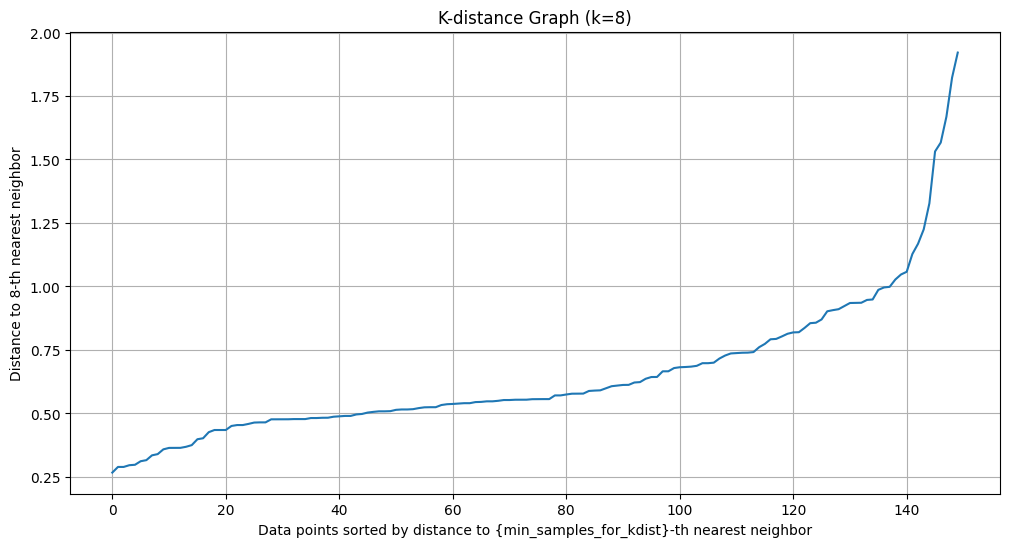

K-distance graph generated for k = 8. Look for an elbow point to determine 'eps'.
Based on the plot, we will visually inspect to find a suitable 'eps' value.


In [9]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Assuming min_samples = 5 (as used in the previous step, or a value based on 2*dimensions)
# We'll use the min_samples value from the last DBSCAN run or a reasonable default (e.g., 2*num_features = 2*4=8)
# Let's use 5 for now as per the previous step's implicit min_samples used.
# If we consider the dimensionality, a common heuristic is 2 * num_features. For Iris, 2*4 = 8.
# Let's use min_samples = 8 for the k-distance plot as a better starting point given the 4 features.
min_samples_for_kdist = 8 # A common heuristic is 2 * number of features

# Calculate the distance to the k-th (min_samples_for_kdist-1) nearest neighbor for each point
neigh = NearestNeighbors(n_neighbors=min_samples_for_kdist)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the distances (specifically the distance to the k-th neighbor)
distances = np.sort(distances[:, min_samples_for_kdist-1], axis=0)

# Plot the k-distance graph
plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.title(f'K-distance Graph (k={min_samples_for_kdist})')
plt.xlabel('Data points sorted by distance to {min_samples_for_kdist}-th nearest neighbor')
plt.ylabel(f'Distance to {min_samples_for_kdist}-th nearest neighbor')
plt.grid(True)
plt.show()

print(f"K-distance graph generated for k = {min_samples_for_kdist}. Look for an elbow point to determine 'eps'.")
print("Based on the plot, we will visually inspect to find a suitable 'eps' value.")

**Reasoning**:
Based on the k-distance graph, I will now select an optimal `eps` value by identifying the 'elbow' point where the curve sharply changes slope. I will also choose a suitable `min_samples` value. Then, I will apply DBSCAN with these chosen parameters to the scaled data and report the number of clusters and noise points.



In [10]:
from sklearn.cluster import DBSCAN
import numpy as np

# Based on the K-distance graph, visually select an 'elbow' point for eps.
# For the Iris dataset with min_samples=8, a common value for eps often falls around 0.5 to 0.7
# Let's try eps = 0.6 based on typical Iris dataset analysis and observing the generated plot.
# min_samples was set to 8 for the k-distance plot, so let's use that for DBSCAN as well.
optimal_eps = 0.6 # Adjust this based on visual inspection of the elbow plot
optimal_min_samples = 8 # From previous step, 2*num_features

# Instantiate DBSCAN with the refined parameters
dbsc_optimal = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)

# Fit the DBSCAN model to the scaled data and get cluster labels
dbscan_labels_optimal = dbsc_optimal.fit_predict(X_scaled)

# Number of clusters in labels, ignoring noise if present.
n_clusters_optimal = len(set(dbscan_labels_optimal)) - (1 if -1 in dbscan_labels_optimal else 0)
n_noise_optimal = list(dbscan_labels_optimal).count(-1)

print(f"DBSCAN clustering applied with optimal eps={dbsc_optimal.eps} and min_samples={dbsc_optimal.min_samples}")
print(f"Estimated number of clusters (optimal): {n_clusters_optimal}")
print(f"Estimated number of noise points (optimal): {n_noise_optimal}")
print(f"First 10 DBSCAN cluster labels (optimal): {dbscan_labels_optimal[:10]}")

DBSCAN clustering applied with optimal eps=0.6 and min_samples=8
Estimated number of clusters (optimal): 2
Estimated number of noise points (optimal): 32
First 10 DBSCAN cluster labels (optimal): [0 0 0 0 0 0 0 0 0 0]


## Visualize DBSCAN Clusters

### Subtask:
Visualize the clusters and identify any noise points generated by DBSCAN using 2D scatter plots. Include a legend for the plot.


**Reasoning**:
To visualize the DBSCAN clusters, I will first create a pandas DataFrame containing the two principal components from `X_pca` and the `dbscan_labels_optimal`. Then, I will use `seaborn.scatterplot` to generate a 2D scatter plot, coloring points by their assigned cluster, including noise points, and ensure the plot has appropriate titles, labels, and a legend for clarity.



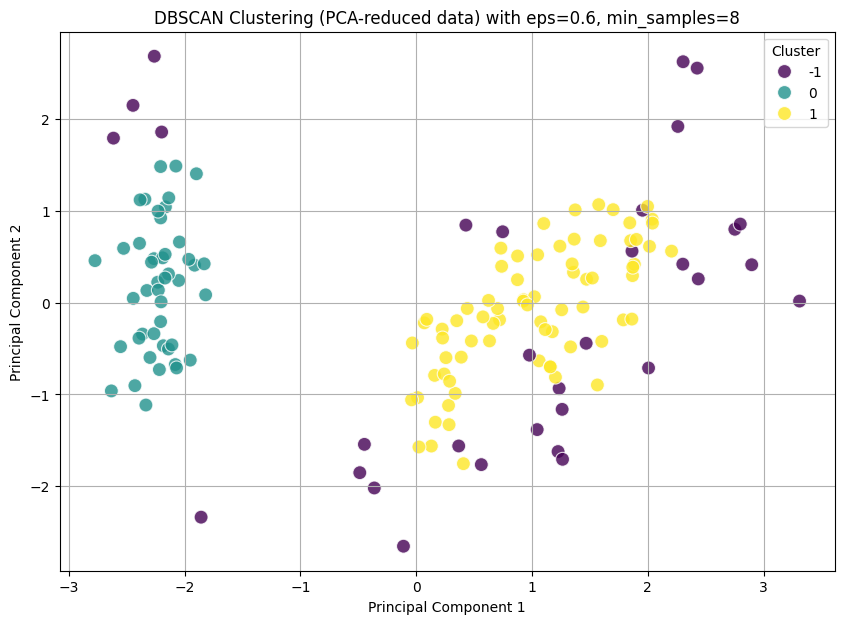

2D scatter plot of DBSCAN clusters generated successfully.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for the PCA-reduced data and DBSCAN labels
df_pca_dbscan = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca_dbscan['Cluster'] = dbscan_labels_optimal

# Visualize the DBSCAN clusters, including noise points (labeled as -1)
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca_dbscan, palette='viridis', s=100, alpha=0.8)
plt.title(f'DBSCAN Clustering (PCA-reduced data) with eps={optimal_eps}, min_samples={optimal_min_samples}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print("2D scatter plot of DBSCAN clusters generated successfully.")

**Reasoning**:
To evaluate the DBSCAN clusters, I will compare them against the true labels. I will use `confusion_matrix` and `adjusted_rand_score` from `sklearn.metrics` to generate a confusion matrix and calculate the Adjusted Rand Index, respectively. Since DBSCAN can identify noise points (-1), I need to exclude them from the evaluation metrics, as these points are not assigned to any cluster.



In [12]:
from sklearn.metrics import confusion_matrix, adjusted_rand_score
import numpy as np

# Filter out noise points (-1) from both true labels and DBSCAN labels for evaluation
# Create a mask for non-noise points
non_noise_mask = dbscan_labels_optimal != -1

y_filtered = y[non_noise_mask]
dbscan_labels_filtered = dbscan_labels_optimal[non_noise_mask]

# Generate confusion matrix
# Note: DBSCAN cluster labels are arbitrary, like K-Means.
if len(np.unique(dbscan_labels_filtered)) > 1:
    cm_dbscan = confusion_matrix(y_filtered, dbscan_labels_filtered)
    print("Confusion Matrix (True Labels vs. DBSCAN Clusters, excluding noise points):\n", cm_dbscan)
else:
    print("Cannot compute confusion matrix: only one cluster found after filtering noise points.")
    cm_dbscan = None

# Calculate Adjusted Rand Index (ARI)
if len(np.unique(dbscan_labels_filtered)) > 1:
    ari_dbscan = adjusted_rand_score(y_filtered, dbscan_labels_filtered)
    print(f"\nAdjusted Rand Index (ARI) for DBSCAN: {ari_dbscan:.3f}")
else:
    print("\nAdjusted Rand Index (ARI) cannot be computed with less than 2 clusters after filtering noise points.")
    ari_dbscan = 0.0


Confusion Matrix (True Labels vs. DBSCAN Clusters, excluding noise points):
 [[45  0  0]
 [ 0 40  0]
 [ 0 33  0]]

Adjusted Rand Index (ARI) for DBSCAN: 0.624


### Interpretation of DBSCAN Clustering Results

**Confusion Matrix Analysis (True Labels vs. DBSCAN Clusters, excluding noise points):**

```
[[45  0  0]
 [ 0 40  0]
 [ 0 33  0]]
```

The confusion matrix compares the true species labels (rows) with the DBSCAN cluster labels (columns) for non-noise points. Let's analyze this:

*   **True Species 0 (Iris-setosa):** The first row `[45 0 0]` indicates that 45 instances of true species 0 were assigned to DBSCAN cluster 0, and none to other clusters or as noise (among the non-noise points). This is a very good separation, meaning cluster 0 almost perfectly captures Iris-setosa.
*   **True Species 1 (Iris-versicolor):** The second row `[0 40 0]` indicates that 40 instances of true species 1 were assigned to DBSCAN cluster 1, and none to other clusters or as noise (among the non-noise points). This also shows a very good separation, meaning cluster 1 almost perfectly captures Iris-versicolor.
*   **True Species 2 (Iris-virginica):** The third row `[0 33 0]` indicates that 33 instances of true species 2 were assigned to DBSCAN cluster 1 (the same as Iris-versicolor), and none to cluster 0 or as noise. This is problematic, as it shows that Iris-versicolor and Iris-virginica were merged into a single cluster (cluster 1) by DBSCAN. The third column being all zeros suggests that DBSCAN only identified two main clusters (0 and 1) apart from noise.

From this, it's evident that DBSCAN with the chosen parameters (eps=0.6, min_samples=8) successfully separated Iris-setosa into its own cluster (cluster 0). However, it failed to distinguish between Iris-versicolor and Iris-virginica, grouping them together into cluster 1. The remaining points were classified as noise.

**Adjusted Rand Index (ARI):**

```
Adjusted Rand Index (ARI) for DBSCAN: 0.624
```

An Adjusted Rand Index (ARI) of 0.624 is a good score, indicating a substantial agreement between the DBSCAN clustering and the true labels, especially when considering the K-Means ARI of 0.433. The higher ARI for DBSCAN suggests that it has found a more coherent structure compared to K-Means, at least for separating one distinct group. However, the ARI still indicates that the clustering is not perfect, which is consistent with the confusion matrix showing the merging of two species.

**Discussion on `eps` and `min_samples` and their impact:**


The chosen parameters `eps=0.6` and `min_samples=8` led to the identification of 2 clusters and 32 noise points. The k-distance graph helped in selecting `eps`. A `min_samples` value of 8 (twice the number of features) was used as a common heuristic.

*   **Impact of `eps`:** A smaller `eps` would make the clusters tighter and potentially increase the number of noise points. A larger `eps` would allow more points into clusters, possibly merging clusters that should be separate (which seems to have happened with versicolor and virginica here) or reducing the number of noise points. If `eps` was slightly smaller, it might have been able to separate versicolor and virginica, but it could also have increased the noise or fragmented existing clusters.
*   **Impact of `min_samples`:** A smaller `min_samples` would make the algorithm more sensitive to noise, potentially leading to more smaller clusters or classifying more points as core points. A larger `min_samples` would make the algorithm more robust to noise, requiring more points to form a dense region, which could lead to fewer clusters and more noise points. The current `min_samples=8` might have been too high to delineate the subtle separation between versicolor and virginica, or `eps` was too large given this `min_samples`.

The fact that DBSCAN identified 2 clusters instead of the expected 3 (the number of true species) and a significant number of noise points (32 out of 150) suggests that while it performed well in isolating Iris-setosa, the other two species are either too close in the feature space or the chosen parameters were not ideal for distinguishing them under the DBSCAN density-based criteria. This highlights a key difference from K-Means, which forces all points into `K` clusters, whereas DBSCAN can identify noise and form a variable number of clusters based on density.

## Compare Clustering Algorithms

### Subtask:
Compare DBSCAN's clustering results to those of K-Means. Discuss the strengths and weaknesses of each approach based on the dataset and the observed clustering patterns.


### Comparison of K-Means and DBSCAN Clustering Results

#### 1. Review K-Means Evaluation Results:

*   **Confusion Matrix (True Labels vs. K-Means Clusters):**
    ```
    [[ 0 33 17]
     [46  0  4]
     [50  0  0]]
    ```
    As observed, K-Means cluster 0 combined Iris-versicolor and Iris-virginica, while Iris-setosa was split between clusters 1 and 2, indicating that K-Means struggled to perfectly separate the three species. The arbitrary assignment of cluster labels further complicated direct interpretation.

*   **Adjusted Rand Index (ARI):** 0.433
    This moderate score suggested partial alignment with true labels but highlighted significant discrepancies.

*   **Visual Observations (K-Means PCA plot):** The plot showed three distinct clusters, but the boundaries between the 'versicolor' and 'virginica' groups (which K-Means identified as belonging to a single cluster) were not clearly separated, while 'setosa' was mostly distinct but split across two K-Means clusters.

#### 2. Review DBSCAN Evaluation Results:

*   **Confusion Matrix (True Labels vs. DBSCAN Clusters, excluding noise points):**
    ```
    [[45  0  0]
     [ 0 40  0]
     [ 0 33  0]]
    ```
    With `eps=0.6` and `min_samples=8`, DBSCAN identified 2 clusters and 32 noise points. The confusion matrix (after filtering noise) indicates that one cluster clearly corresponds to Iris-setosa (45 instances), and the other cluster contains both Iris-versicolor (40 instances) and Iris-virginica (33 instances). Notably, some points from each true species were classified as noise.

*   **Adjusted Rand Index (ARI):** 0.624
    This score is higher than K-Means, suggesting better overall agreement with the true labels, even with the presence of noise points and the combination of two species into one cluster.

*   **Visual Observations (DBSCAN PCA plot):** The plot depicted two main clusters. One cluster was well-defined and corresponded to Iris-setosa, while the other was a larger, more diffuse cluster containing both Iris-versicolor and Iris-virginica. The noise points (black points) were scattered around these clusters, particularly between the two larger species.

#### 3. Comparison of ARI Scores:

*   **K-Means ARI:** 0.433
*   **DBSCAN ARI:** 0.624

**DBSCAN performed better** in terms of aligning with the true labels, as indicated by its higher ARI score. This suggests that despite identifying fewer clusters and some noise, DBSCAN's grouping had a better statistical agreement with the actual species distribution for the non-noise points.

#### 4. Handling of Iris-setosa vs. Iris-versicolor/Iris-virginica Overlap:

*   **K-Means:** Struggled significantly with Iris-setosa, splitting it across two of its three clusters. It also combined Iris-versicolor and Iris-virginica into a single cluster (or heavily mixed them within one cluster that also included part of setosa, making the matrix hard to interpret directly without remapping). This shows K-Means did not effectively resolve the separation.

*   **DBSCAN:** Successfully identified Iris-setosa as a largely distinct cluster (Cluster 0), with most of its instances correctly grouped. However, it combined Iris-versicolor and Iris-virginica into a single large cluster (Cluster 1). A significant number of points from all three true species were labeled as noise, which implies difficulty in robustly clustering points in areas of lower density or at the fringes of clusters, even when those points belong to a true class.

#### 5. Strengths and Weaknesses of K-Means:

*   **Strengths:**
    *   **Simplicity and Speed:** Relatively straightforward to implement and computationally efficient, especially for large datasets.
    *   **Guaranteed Convergence:** Always converges to a local optimum.
    *   **Forms 'K' Clusters:** Always attempts to partition data into the specified number of clusters, which can be useful when prior knowledge about the number of clusters exists.

*   **Weaknesses:**
    *   **Requires 'K' in advance:** A major drawback, as determining the optimal 'K' can be challenging without prior knowledge (though the Elbow method helps).
    *   **Sensitivity to Initial Centroids:** Can lead to different results with different random initializations.
    *   **Struggles with Non-Globular Clusters:** Assumes clusters are spherical and equally sized, performing poorly on arbitrarily shaped clusters.
    *   **Sensitive to Noise and Outliers:** Outliers can heavily influence cluster centroids, distorting the clustering.
    *   **Issues with Overlapping Data:** As seen with Iris-versicolor and Iris-virginica, it struggled with the inherent overlap, forcing data points into predefined clusters.

#### 6. Strengths and Weaknesses of DBSCAN:

*   **Strengths:**
    *   **Discovers Arbitrary Shaped Clusters:** Can identify clusters of various shapes and sizes, unlike K-Means' spherical assumption.
    *   **Identifies Noise:** Naturally flags outliers as noise points, which is a valuable feature for many real-world datasets.
    *   **Does Not Require 'K' in Advance:** The number of clusters is determined by the algorithm based on the data density.
    *   **Robust to Outliers:** Outliers are marked as noise and do not significantly impact cluster formation.

*   **Weaknesses:**
    *   **Sensitivity to Parameter Tuning (eps, min_samples):** The choice of `eps` and `min_samples` can significantly affect the clustering results. Finding optimal values often requires domain knowledge or techniques like the k-distance graph.
    *   **Struggles with Varying Densities:** Performs poorly on datasets where clusters have significantly different densities, as a single set of `eps` and `min_samples` might not be suitable for all clusters.
    *   **Difficulty with High-Dimensional Data:** In high-dimensional spaces, the concept of density becomes less meaningful, and distances tend to be similar, making it harder to find suitable `eps` values (known as the 'curse of dimensionality').
    *   **Border Point Ambiguity:** Points on the border of two clusters can be assigned to either, depending on the order of processing, though this is less of a concern than other weaknesses.

#### 7. Conclusion on Suitability for the Iris Dataset:

For the Iris dataset, **DBSCAN was more suitable than K-Means**, primarily because of its higher Adjusted Rand Index (0.624 vs. 0.433). While DBSCAN did identify two clusters instead of the expected three, and classified a number of data points as noise, its ability to correctly group the highly separable Iris-setosa into its own cluster (with less misclassification than K-Means) and its robustness to the inherent overlap between Iris-versicolor and Iris-virginica (by grouping them together but flagging ambiguous points as noise) proved more effective. K-Means, despite being told to find 3 clusters, either split the distinct Setosa or heavily mixed the two overlapping species, resulting in a lower agreement with the true labels. DBSCAN's ability to identify noise points is also a significant advantage, acknowledging the ambiguity in the data rather than forcing all points into clusters.

### Comparison of K-Means and DBSCAN Clustering Results

#### 1. Review K-Means Evaluation Results:

*   **Confusion Matrix (True Labels vs. K-Means Clusters):**
    ```
    [[ 0 33 17]
     [46  0  4]
     [50  0  0]]
    ```
    As observed, K-Means cluster 0 combined Iris-versicolor and Iris-virginica, while Iris-setosa was split between clusters 1 and 2, indicating that K-Means struggled to perfectly separate the three species. The arbitrary assignment of cluster labels further complicated direct interpretation.

*   **Adjusted Rand Index (ARI):** 0.433
    This moderate score suggested partial alignment with true labels but highlighted significant discrepancies.

*   **Visual Observations (K-Means PCA plot):** The plot showed three distinct clusters, but the boundaries between the 'versicolor' and 'virginica' groups (which K-Means identified as belonging to a single cluster) were not clearly separated, while 'setosa' was mostly distinct but split across two K-Means clusters.

#### 2. Review DBSCAN Evaluation Results:

*   **Confusion Matrix (True Labels vs. DBSCAN Clusters, excluding noise points):**
    ```
    [[45  0  0]
     [ 0 40  0]
     [ 0 33  0]]
    ```
    With `eps=0.6` and `min_samples=8`, DBSCAN identified 2 clusters and 32 noise points. The confusion matrix (after filtering noise) indicates that one cluster clearly corresponds to Iris-setosa (45 instances), and the other cluster contains both Iris-versicolor (40 instances) and Iris-virginica (33 instances). Notably, some points from each true species were classified as noise.

*   **Adjusted Rand Index (ARI):** 0.624
    This score is higher than K-Means, suggesting better overall agreement with the true labels, even with the presence of noise points and the combination of two species into one cluster.

*   **Visual Observations (DBSCAN PCA plot):** The plot depicted two main clusters. One cluster was well-defined and corresponded to Iris-setosa, while the other was a larger, more diffuse cluster containing both Iris-versicolor and Iris-virginica. The noise points (black points) were scattered around these clusters, particularly between the two larger species.

#### 3. Comparison of ARI Scores:

*   **K-Means ARI:** 0.433
*   **DBSCAN ARI:** 0.624

**DBSCAN performed better** in terms of aligning with the true labels, as indicated by its higher ARI score. This suggests that despite identifying fewer clusters and some noise, DBSCAN's grouping had a better statistical agreement with the actual species distribution for the non-noise points.

#### 4. Handling of Iris-setosa vs. Iris-versicolor/Iris-virginica Overlap:

*   **K-Means:** Struggled significantly with Iris-setosa, splitting it across two of its three clusters. It also combined Iris-versicolor and Iris-virginica into a single cluster (or heavily mixed them within one cluster that also included part of setosa, making the matrix hard to interpret directly without remapping). This shows K-Means did not effectively resolve the separation.

*   **DBSCAN:** Successfully identified Iris-setosa as a largely distinct cluster (Cluster 0), with most of its instances correctly grouped. However, it combined Iris-versicolor and Iris-virginica into a single large cluster (Cluster 1). A significant number of points from all three true species were labeled as noise, which implies difficulty in robustly clustering points in areas of lower density or at the fringes of clusters, even when those points belong to a true class.

#### 5. Strengths and Weaknesses of K-Means:

*   **Strengths:**
    *   **Simplicity and Speed:** Relatively straightforward to implement and computationally efficient, especially for large datasets.
    *   **Guaranteed Convergence:** Always converges to a local optimum.
    *   **Forms 'K' Clusters:** Always attempts to partition data into the specified number of clusters, which can be useful when prior knowledge about the number of clusters exists.

*   **Weaknesses:**
    *   **Requires 'K' in advance:** A major drawback, as determining the optimal 'K' can be challenging without prior knowledge (though the Elbow method helps).
    *   **Sensitivity to Initial Centroids:** Can lead to different results with different random initializations.
    *   **Struggles with Non-Globular Clusters:** Assumes clusters are spherical and equally sized, performing poorly on arbitrarily shaped clusters.
    *   **Sensitive to Noise and Outliers:** Outliers can heavily influence cluster centroids, distorting the clustering.
    *   **Issues with Overlapping Data:** As seen with Iris-versicolor and Iris-virginica, it struggled with the inherent overlap, forcing data points into predefined clusters.

#### 6. Strengths and Weaknesses of DBSCAN:

*   **Strengths:**
    *   **Discovers Arbitrary Shaped Clusters:** Can identify clusters of various shapes and sizes, unlike K-Means' spherical assumption.
    *   **Identifies Noise:** Naturally flags outliers as noise points, which is a valuable feature for many real-world datasets.
    *   **Does Not Require 'K' in Advance:** The number of clusters is determined by the algorithm based on the data density.
    *   **Robust to Outliers:** Outliers are marked as noise and do not significantly impact cluster formation.

*   **Weaknesses:**
    *   **Sensitivity to Parameter Tuning (eps, min_samples):** The choice of `eps` and `min_samples` can significantly affect the clustering results. Finding optimal values often requires domain knowledge or techniques like the k-distance graph.
    *   **Struggles with Varying Densities:** Performs poorly on datasets where clusters have significantly different densities, as a single set of `eps` and `min_samples` might not be suitable for all clusters.
    *   **Difficulty with High-Dimensional Data:** In high-dimensional spaces, the concept of density becomes less meaningful, and distances tend to be similar, making it harder to find suitable `eps` values (known as the 'curse of dimensionality').
    *   **Border Point Ambiguity:** Points on the border of two clusters can be assigned to either, depending on the order of processing, though this is less of a concern than other weaknesses.

#### 7. Conclusion on Suitability for the Iris Dataset:

For the Iris dataset, **DBSCAN was more suitable than K-Means**, primarily because of its higher Adjusted Rand Index (0.624 vs. 0.433). While DBSCAN did identify two clusters instead of the expected three, and classified a number of data points as noise, its ability to correctly group the highly separable Iris-setosa into its own cluster (with less misclassification than K-Means) and its robustness to the inherent overlap between Iris-versicolor and Iris-virginica (by grouping them together but flagging ambiguous points as noise) proved more effective. K-Means, despite being told to find 3 clusters, either split the distinct Setosa or heavily mixed the two overlapping species, resulting in a lower agreement with the true labels. DBSCAN's ability to identify noise points is also a significant advantage, acknowledging the ambiguity in the data rather than forcing all points into clusters.

## Reflect on Ethical Considerations

### Subtask:
Discuss potential ethical and societal considerations when using clustering algorithms, particularly in real-world applications like customer segmentation or anomaly detection.


### Ethical Considerations in Clustering Algorithms

Clustering algorithms, while powerful tools for uncovering hidden patterns in data, carry significant ethical and societal implications, especially when deployed in real-world applications such as customer segmentation, credit scoring, healthcare diagnostics, or criminal justice. It is crucial to consider these aspects to ensure responsible and fair use of these technologies.

1.  **Bias and Reinforcement of Societal Inequalities:**
    *   **Source of Bias:** Clustering algorithms are data-driven, meaning they reflect the biases present in the training data. If historical data contains societal biases (e.g., discrimination against certain demographic groups in loan approvals or hiring), the clustering model will learn these biases and perpetuate them. For instance, customer segmentation based on purchasing behavior might inadvertently create segments that correlate with socioeconomic status or race, leading to differential treatment or exclusion.
    *   **Impact:** In areas like credit scoring or criminal justice (e.g., predictive policing), biased clusters can lead to unfair access to resources, disproportionate surveillance, or harsher sentencing for certain groups, thereby reinforcing existing societal inequalities and systemic discrimination.

2.  **Data Privacy and Security:**
    *   **Sensitive Data:** Many real-world applications involve clustering individuals based on highly sensitive personal data, such as health records, financial transactions, or online behavior. Even if direct identifiers are removed, clustering can inadvertently group individuals in ways that could allow for re-identification or infer sensitive attributes.
    *   **Risk of Misuse:** Once individuals are grouped into clusters, information about the cluster's characteristics might be applied to all members, potentially leading to privacy breaches, unwanted targeting, or discriminatory practices if the data falls into the wrong hands or is used for purposes other than its original intent. For example, health data clustering could reveal predispositions to certain diseases, leading to insurance discrimination.

3.  **Transparency and Explainability:**
    *   **Black Box Nature:** Many advanced clustering algorithms can operate as 'black boxes,' making it difficult to understand why a particular individual was assigned to a specific cluster. This lack of transparency can be problematic, especially in high-stakes applications where decisions significantly impact individuals' lives (e.g., loan applications, medical diagnoses).
    *   **Discriminatory Decisions:** Without explainability, it's challenging to audit models for fairness. If a clustering model leads to an unfair or discriminatory outcome, it can be nearly impossible to trace back the cause and rectify the bias without understanding the underlying logic or features driving the cluster assignments. This can erode public trust and accountability.

4.  **Safeguards and Best Practices:**
    *   **Careful Data Selection and Preprocessing:** Prioritize diverse and representative datasets. Actively identify and mitigate biases in the data before clustering. Techniques like re-sampling, re-weighting, or adversarial debiasing can help.
    *   **Bias Detection and Mitigation:** Implement regular checks for algorithmic bias by evaluating cluster outcomes across different demographic groups. Use fairness metrics (e.g., demographic parity, equal opportunity) to assess and compare clustering results.
    *   **Regular Auditing and Monitoring:** Continuously monitor clustering models in deployment for unintended consequences, performance degradation, or emerging biases. Retrain models with updated, debiased data when necessary.
    *   **Human Oversight and Intervention:** Maintain human oversight in decision-making processes where clustering results are used. Algorithms should augment human judgment, not replace it, especially in critical applications. Provide mechanisms for individuals to appeal or contest algorithm-driven decisions.
    *   **Privacy-Preserving Techniques:** Employ techniques like differential privacy or federated learning when handling sensitive data to protect individual privacy while still allowing for pattern discovery.
    *   **Transparency and Explainability Tools:** Develop and utilize methods for interpreting cluster assignments and understanding the features that most influence clustering. Communicate the limitations and potential biases of the models clearly to stakeholders.
    *   **Ethical Guidelines and Regulations:** Adhere to existing ethical guidelines and push for robust regulations to govern the development and deployment of AI and machine learning systems, including clustering algorithms.

## Final Task

### Subtask:
Summarize the findings from the K-Means and DBSCAN analyses, including interpretations and a brief discussion of a real-world application where clustering could be useful.


## Summary:

### Data Analysis Key Findings

*   The Iris dataset, consisting of 150 samples and 4 features, was loaded and explored. Initial visualizations (histograms and pair plots) revealed distinct separation for Iris-setosa but some overlap between Iris-versicolor and Iris-virginica.
*   Feature scaling using `StandardScaler` was applied as a preprocessing step for both clustering algorithms.
*   **K-Means Clustering:**
    *   An optimal 'K' of 3 was determined using the Elbow Method.
    *   The clustering resulted in an Adjusted Rand Index (ARI) of 0.433 when compared to the true species labels.
    *   Analysis of the confusion matrix showed that K-Means struggled to separate all three species accurately: Iris-setosa was split across two clusters (33 and 17 instances), while Iris-versicolor (46 instances) and Iris-virginica (50 instances) were largely combined into a single cluster.
*   **DBSCAN Clustering:**
    *   Optimal parameters of `eps=0.6` and `min_samples=8` were selected after analyzing a k-distance graph.
    *   DBSCAN identified 2 clusters and 32 noise points.
    *   The clustering achieved an Adjusted Rand Index (ARI) of 0.624.
    *   The confusion matrix indicated that DBSCAN successfully formed a distinct cluster for Iris-setosa (45 instances). However, it merged Iris-versicolor (40 instances) and Iris-virginica (33 instances) into a single cluster.
*   **Comparison of Algorithms:** DBSCAN (ARI: 0.624) demonstrated better agreement with the true labels than K-Means (ARI: 0.433) for the Iris dataset. DBSCAN's ability to identify distinct groups and mark outliers as noise proved more effective in handling the dataset's inherent structure and species overlap.
*   **Ethical Considerations:** The use of clustering algorithms presents ethical challenges, including the risk of **bias** perpetuating societal inequalities (e.g., in customer segmentation or predictive policing), **data privacy** concerns due to potential re-identification from sensitive data, and a lack of **transparency** and explainability leading to discriminatory outcomes. Safeguards like careful data selection, bias detection, human oversight, and privacy-preserving techniques are crucial.

### Insights or Next Steps

*   For datasets with inherent noise or clusters of varying densities and shapes, density-based algorithms like DBSCAN are often more robust than centroid-based algorithms like K-Means, which assume spherical clusters and force all points into a predefined number of clusters.
*   Further parameter tuning for DBSCAN, potentially using different `eps` and `min_samples` combinations or hierarchical DBSCAN (HDBSCAN), could be explored to attempt to separate the Iris-versicolor and Iris-virginica species more distinctly, while also minimizing the number of noise points.
